# **Mapping and Perception for an autonomous robot (0510-7951)**

Written by Roy Orfaig

2026B

#Exercise 1:
---
**Part A**

Experience with the KITTI dataset [**Robotic kit components**](https://www.cvlibs.net/datasets/kitti/) and [**pykitti tool**](https://pypi.org/project/pykitti/)

**Part B**

Robot mapping based on [**probability occupancy grid**](https://ieeexplore.ieee.org/document/8666170)

**Part C**

Sensor fusion and Road segemenation based on [**DeepLABv3+**](https://arxiv.org/abs/1703.06870) neural network

-------------------------------------

**Instructions**

1. Fill in the code the "TODO" section.

2. **Please copy all the results to the report:**
    - Include outputs such as images, tables, scores, etc.
    - Add performance metrics, analysis, and your explanations.
    - Attach the completed notebook/python code to the report package.

3. Download and extract project data to your Google Drive

  1.   Install Google Drive on your desktop.
  2.   Save this notebook to your Google Drive by clicking `Save a copy
       in Drive` from the `File` menu.

  3. Visit the [**KITTI dataset**](http://www.cvlibs.net/datasets/kitti/) website ,and download the specific record you need (chose "sync" recording)
  5. Upload the record to you goole drive account. Mount the recorcds to the notebook.
  6. Another way to download the records to Google Drive instead of following steps 4 and 5, you can download the records directly to your Google Drive via Colab. (Refer to the commands provided in the comments below.)

  6. The provided Git repository include example of records ('0117'), you can use it to understand how to organize the format folders for the pykitti toolbox. Note: The example does not include all files, only a subset.

Good luck!

###REFERENCES

[1] The full KITTI datased can be accessed here: http://www.cvlibs.net/datasets/kitti/.

[2] KITTI Dataset paper: A. Geiger, P. Lenz, C. Stiller and R. Urtasun, "Vision meets Robotics: The KITTI Dataset," International Journal of Robotics Research (IJRR), vol. 32, no. 11, pp. 1231-1237 2013.

[3] Description of Occupancy Grid Map (OGM) estimation: Z. Luo, M. V. Mohrenschilt and S. Habibi, "A probability occupancy grid based approach for real-time LiDAR ground segmentation," IEEE Transactions on Intelligent Transportation Systems, vol 21, no. 3, pp. 998–1010, Mar. 2020.

[4] Paper of DeepLab v3+ for image segmentation: L. C. Chen, Y. Zhu, G. Apandreou, F. Schroff and H. Adam, “Encoder-decoder with atrous separable convolution for semantic image segmentation,” ECCV 2018 Lecture Notes in Computer Science, vol. 11211, pp. 833–851, 2018.

[5] DeepLab v3+ paper via arXiv: https://arxiv.org/abs/1802.02611.

[6] DeepLab v3+ repository: https://github.com/tensorflow/models/tree/master/research/deeplab.

[7] This tutorial use pykitti module to load the KITTI dataset: https://github.com/utiasSTARS/pykitti.

In [699]:
#TODO#

# Name of student: Doron Katzir
# ID 307858894
# Record number: 2011_09_26_drive_0064

In [700]:
## To import google drive, write this code in code section of colab and run it
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [701]:
# optional- download your records directly to google drive- an example:
# !wget -P "/content/drive/My Drive/KITTI_Dataset/" https://s3.eu-central-1.amazonaws.com/avg-kitti/raw_data/2011_09_26_drive_0095/2011_09_26_drive_0095_sync.zip
# !unzip "/content/drive/MyDrive/KITTI_Dataset/2011_09_26_drive_0095_sync.zip" -d "/content/drive/MyDrive/KITTI_Dataset/"

## PREPARATION

In [702]:
!git clone https://github.com/orfaig/Course_0510_7951.git

fatal: destination path 'Course_0510_7951' already exists and is not an empty directory.


In [703]:
# First- install pykitti
!pip install pykitti

In [704]:
#second- install the other dependencies
!pip install -r Course_0510_7951/requirements.txt

In [705]:
%matplotlib inline
# Core
import os
import sys
import glob

# Numeric / ML
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.linear_model import RANSACRegressor
from scipy import stats

# Vision / plotting
import cv2
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# 3D / mapping
import open3d as o3d
import pymap3d as pm

# KITTI loader
import pykitti

In [706]:
### Load KITTI Data

# from my google drive (example)
basedir = '/content/drive/MyDrive/Mapping and Perception for an autonomous robot/EX1'
date = '2011_09_26'
drive = '0064'

#directly from colab
# basedir = 'Course_0510_7951/raw_data/'
# date = '2011_09_26'
# drive = '0064'

data = pykitti.raw(basedir, date, drive)



In [707]:
# *********************   LLA Coordinates  *********************
fig_dir_path = os.getcwd() + "/Results_2026B/"
if not os.path.exists(fig_dir_path):
    os.makedirs(fig_dir_path)

#Part A: Geodetic coordinate system and the KITTI dataset

In [708]:
def unpack_params(dataset):
    """
    Extract relevant OXTS (GPS/IMU) parameters from a KITTI dataset object.
    """
    # TODO: Extract GPS position (Latitude, Longitude, Altitude)
    # Hint: access dataset.oxts[i].packet.lat / lon / alt
    lats, lons, alts = [], [], []

    # TODO: Extract Orientation (Roll, Pitch, Yaw)
    rolls, pitches, yaws = [], [], []

    # TODO: Extract Sensor Stats (Number of satellites and Position accuracy)
    # Hint: packet.numsats and packet.pos_accuracy
    num_sats, accs = [], []

    # TODO: Extract Velocities (Forward 'vf' and Leftward 'vl')
    vf, vl = [], []

    # TODO: Extract Timestamps from dataset.timestamps
    times = []

    # Iterate through the dataset and append values to the lists
    for i in range(len(dataset.oxts)):
        packet = dataset.oxts[i].packet

        # GPS
        lats.append(packet.lat)
        lons.append(packet.lon)
        alts.append(packet.alt)

        # Orientation, in radians
        rolls.append(packet.roll)
        pitches.append(packet.pitch)
        yaws.append(packet.yaw)

        # GPS quality
        num_sats.append(packet.numsats)
        accs.append(packet.pos_accuracy)

        # Vehicle-frame velocities, in m/s
        vf.append(packet.vf)   # forward velocity
        vl.append(packet.vl)   # leftward velocity

        # Timestamp
        times.append(dataset.timestamps[i])

    return lats, lons, alts, num_sats, accs, pitches, rolls, yaws, times, vf, vl

In [709]:
# ------------------------------------------------------------
# Extract OXTS parameters from the KITTI dataset.
# This will give us:
#   - GPS data: longitude, latitude, altitude
#   - Satellite info: number of satellites, position accuracy
#   - IMU data: pitch, roll, yaw
#   - Timestamps: time for each measurement
#
# The values are returned as lists, each element corresponding
# to one frame in the dataset.
# ------------------------------------------------------------

lats, lons, alts, num_sats, accs, pitches, rolls, yaws, times,vf,vl = unpack_params(data)

(1.a) Describe technical details about your scenario such as driving route, presence of dynamic objects (cyclists, cars and pedestrians), occlusions, turns etc.

(1.b)
Print the trajectory on google maps using gmplot!

In [710]:
import gmplot
# TODO
lat_arr = np.asarray(lats, dtype=float)
lon_arr = np.asarray(lons, dtype=float)

center_lat = np.mean(lat_arr)
center_lon = np.mean(lon_arr)

gmap = gmplot.GoogleMapPlotter(center_lat, center_lon, 17)
gmap.plot(lat_arr, lon_arr, color='red', edge_width=4)

output_path = os.path.join(fig_dir_path, "Trajectory.html")
gmap.draw(output_path)


print(f"Map saved as: {output_path}")
# open the file Trajectory.html on chrome and see the trajectory on google maps

Map saved as: /content/Results_2026B/Trajectory.html



(1.c) Display the trajectory in local ENU and NED coordinate frames. Plot the measured velocities (forward and right components). Also plot the orientation (roll, pitch, yaw).  
Explain how the vehicle trajectory is related to the measured yaw and velocity components, and describe how turning maneuvers are manifested in the ENU/NED trajectories and in the forward and lateral velocity plots


In [711]:
def Extarct_ENU_NED_RPY(lons, lats, alts):
    """
    Convert GNSS (lat, lon, alt) into local ENU and NED coordinates.
    Origin is fixed at the first sample: (lats[0], lons[0], alts[0]).
    """
    # TODO: Define the reference origin from the first frame
    lat0, lon0, alt0 = lats[0], lons[0], alts[0]

    # --- ENU conversion ---
    ENU_coords_list = []
    for i in range(len(lats)):
        # TODO: Convert geodetic to ENU using pm.geodetic2enu
        e, n, u = pm.geodetic2enu(lats[i], lons[i], alts[i], lat0, lon0, alt0)

        # TODO: Round to 2 decimals (centimeters) and append as np.array
        curr_ENU = np.round(np.array([e, n, u]), 2)
        ENU_coords_list.append(curr_ENU)

    # --- NED conversion ---
    NED_coords_list = []
    for i in range(len(lats)):
        # TODO: Convert geodetic to NED using pm.geodetic2ned
        n_ned, e_ned, d_ned = pm.geodetic2ned(lats[i], lons[i], alts[i],
                                              lat0, lon0, alt0)

        # TODO: Round to 2 decimals (centimeters) and append as np.array
        curr_NED = np.round(np.array([n_ned, e_ned, d_ned]), 2)
        NED_coords_list.append(curr_NED)

    # Stack results into (N, 3) arrays
    return np.array(ENU_coords_list), np.array(NED_coords_list)

In [712]:
ENU_coords_array,NED_coords_array=Extarct_ENU_NED_RPY(lons, lats, alts)

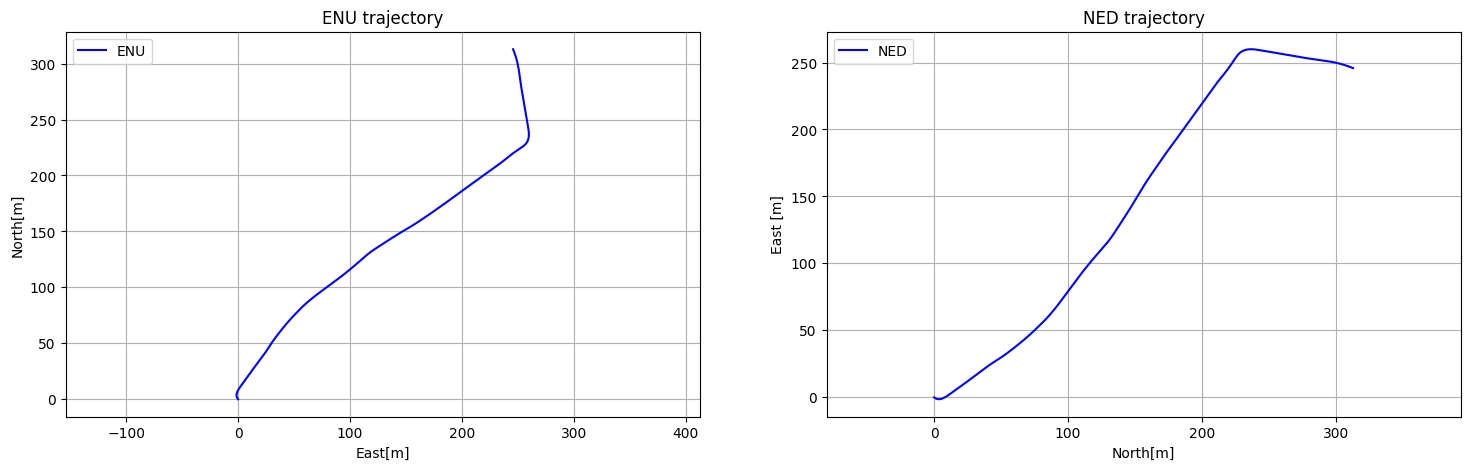

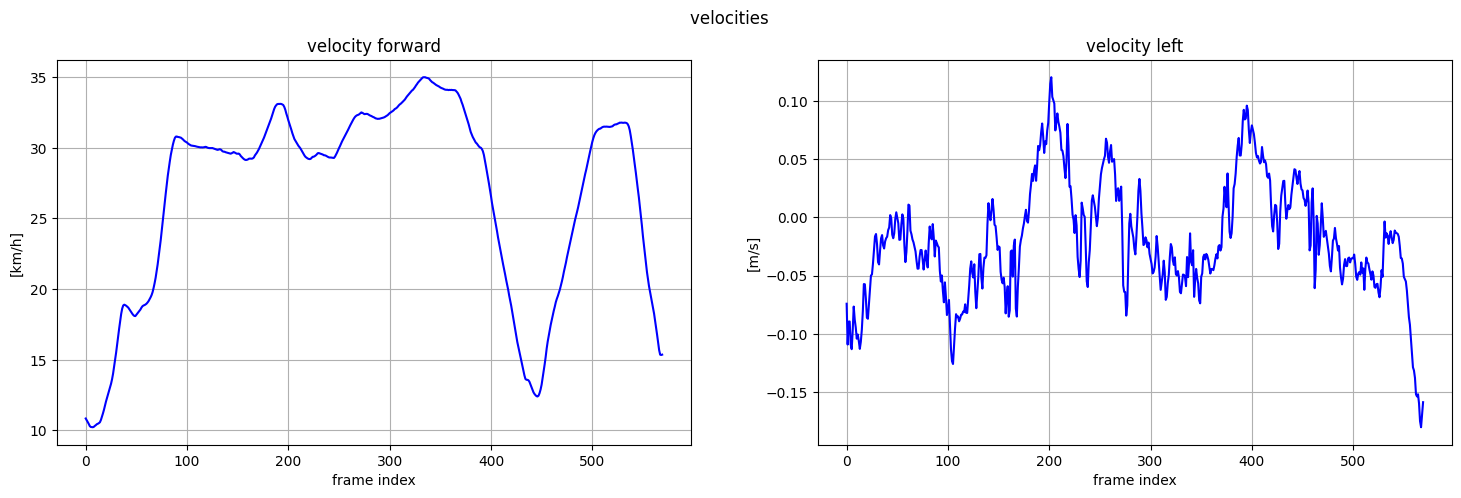

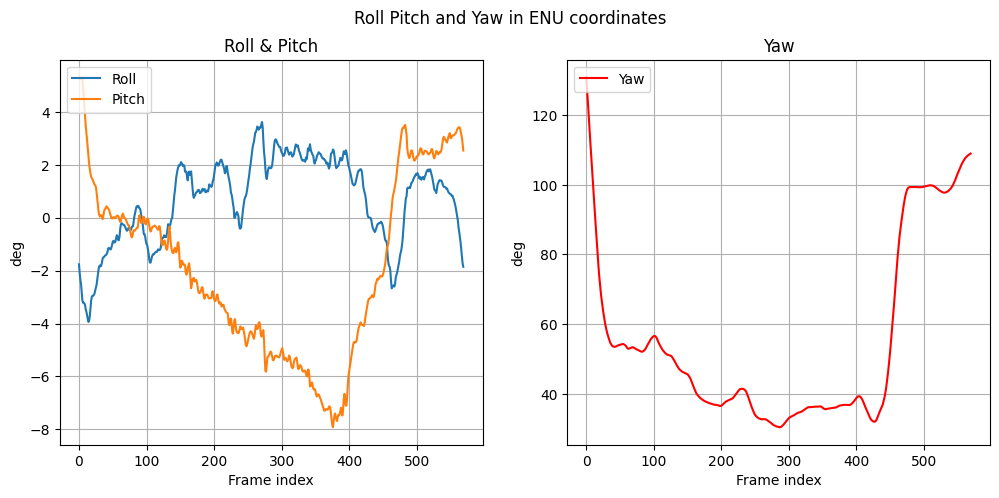

In [713]:
#plotting positions
vf = np.asarray(vf, dtype=float)
vl = np.asarray(vl, dtype=float)

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(18, 5))
ax1.plot(ENU_coords_array[:, 0],ENU_coords_array[:, 1], color="blue")
ax1.set_title('ENU trajectory')
ax1.set(xlabel='East[m]', ylabel='North[m]')
ax1.grid()
ax1.legend(["ENU"], loc='upper left')
ax1.set_aspect('equal', adjustable='datalim')

ax2.plot(NED_coords_array[:, 0],NED_coords_array[:, 1], color="blue")
ax2.set_title('NED trajectory')
ax2.set(xlabel='North[m]', ylabel='East [m]')
ax2.grid()
ax2.legend(["NED"], loc='upper left')
ax2.set_aspect('equal', adjustable='datalim')
plt.savefig(fig_dir_path + "/" + "Trajectories.png")

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(18, 5))
fig.suptitle('velocities ')
ax1.plot(vf*3.6, color="blue")
ax1.set_title('velocity forward')
ax1.set(xlabel='frame index', ylabel='[km/h]')
ax1.grid()

ax2.plot(vl, color="blue")
ax2.set_title('velocity left')
ax2.set(xlabel='frame index', ylabel='[m/s]')
ax2.grid()

plt.savefig(fig_dir_path + "/" + "Velocities.png")
rolls = np.asarray(rolls, dtype=float)
pitches = np.asarray(pitches, dtype=float)
yaws = np.asarray(yaws, dtype=float)
# plotting  orientation
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(12, 5))
fig.suptitle("Roll Pitch and Yaw in ENU coordinates")
ax1.plot(rolls/np.pi*180)
ax1.plot(pitches/np.pi*180)
ax1.set_title('Roll & Pitch')
ax1.set(xlabel='Frame index', ylabel='deg')
ax1.legend(["Roll","Pitch"],loc='upper left')
ax1.grid()
ax2.plot(yaws/np.pi*180,color='r')
ax2.set_title('Yaw')
ax2.set(xlabel='Frame index', ylabel='deg')
ax2.legend(["Yaw"], loc='upper left')
ax2.grid()
plt.savefig(fig_dir_path + "/" + "Roll Pitch and Yaw on ENU coordinates.png")


(1.d) Display the quality of GPS signal reception and any relevant details. Explain the causes and consequences of variations in GPS satellite reception in your scenario.

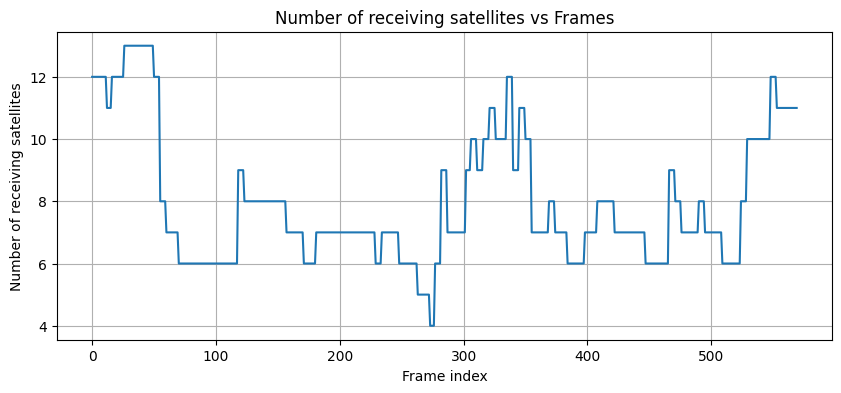

In [714]:

# *********************   PlotSatellites Number  *********************
#TODO# (hint-use: dataset.oxts[i].packet.numsats)

# Collect satellite count
#TODO
satellites_num = np.asarray(
    [data.oxts[i].packet.numsats for i in range(len(data.oxts))],
    dtype=float
)

# Create output directory
fig_dir_path = os.path.join(os.getcwd(), "Results", str(drive))
os.makedirs(fig_dir_path, exist_ok=True)

# Plot
plt.figure(figsize=(10, 4))
plt.title("Number of receiving satellites vs Frames")
plt.plot(satellites_num)
plt.xlabel("Frame index")
plt.ylabel("Number of receiving satellites")
plt.grid(True)

# Save image
save_path = os.path.join(fig_dir_path, "Number_of_receiving_satellites.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight')

# Show inline in Colab
plt.show()


(1.e) Present one example of a camera image and its corresponding registered LiDAR point cloud from the dataset.
Identify elements in the scene that are difficult to perceive using only the camera or only the LiDAR. Explain the limitations of each sensor and how sensor fusion addresses these challenges


In [715]:
##Load point cloud data (LiDAR) and Image
def load_data(data,idx):
  ### Get the image data
  img_raw =   np.asarray(data.get_cam2(idx)) #TODO #(hint- use get_cam2 in pykitti)
  ### Get the LiDAR data (only x,y,z without the intensity) , (hint use get_velo )
  lidar_raw = data.get_velo(idx) #TODO
  return img_raw, lidar_raw[:,:3] #TODO

In [716]:
#idx=#TODO
idx=1
img_raw,lidar_raw = load_data(data,idx)
pc=lidar_raw.T
### Visualize
dataf = []
x=pc[0,:];
point_size = np.full(x.shape, 2)
fig = px.scatter_3d(x=pc[0, :], y=pc[1, :], z=pc[2, :], size=point_size, opacity=1)
dataf = [go.Scatter3d(x=pc[0, :], y=pc[1, :], z=pc[2, :], mode="markers", marker=dict(size=2,color=pc[2,:],colorscale='Viridis'))]
mega_centroid = np.average(pc, axis=1)
mega_max = np.amax(pc, axis=1)
mega_min = np.amin(pc, axis=1)
lower_bound = mega_centroid - (np.amax(mega_max - mega_min) / 2)
upper_bound = mega_centroid + (np.amax(mega_max - mega_min) / 2)

show_grid_lines=True
# Setup layout
grid_lines_color = 'rgb(127, 127, 127)' if show_grid_lines else 'rgb(30, 30, 30)'
layout = go.Layout(scene=dict(
        xaxis=dict(nticks=8,
                range=[lower_bound[0], upper_bound[0]],
                showbackground=True,
                backgroundcolor='rgb(30, 30, 30)',
                gridcolor=grid_lines_color,
                zerolinecolor=grid_lines_color),
        yaxis=dict(nticks=8,
                range=[lower_bound[1], upper_bound[1]],
                showbackground=True,
                backgroundcolor='rgb(30, 30, 30)',
                gridcolor=grid_lines_color,
                zerolinecolor=grid_lines_color),
        zaxis=dict(nticks=8,
                range=[lower_bound[2], upper_bound[2]],
                showbackground=True,
                backgroundcolor='rgb(30, 30, 30)',
                gridcolor=grid_lines_color,
                zerolinecolor=grid_lines_color),
        xaxis_title="x (meters)",
        yaxis_title="y (meters)",
        zaxis_title="z (meters)"
    ),
    margin=dict(r=10, l=10, b=10, t=10),
    paper_bgcolor='rgb(30, 30, 30)',
    font=dict(
        family="Courier New, monospace",
        color=grid_lines_color
    ),
    legend=dict(
        font=dict(
            family="Courier New, monospace",
            color='rgb(127, 127, 127)'
        )
    )
)

fig = go.Figure(data=dataf,layout=layout)
fig.show()

Output hidden; open in https://colab.research.google.com to view.

#Part B: Probabilistic Occupancy Grid

 Implementation of a grid on a single scan based on the following instructions

 1. find a drivable path in the session, use a naïve role: filter all the point clouds above ~30 cm off the ground (assume flat surface).

In [717]:
# Step 1
# You need to take a LiDAR point cloud as input and output a naive segmentation of
# obstacle points and drivable (free/road) areas.
# Remember to filter out irrelevant points (e.g., returns from the vehicle itself)
# and to account for height (z) when deciding what belongs to the road vs. obstacles.
# Also filter out height obstacles that do not obstruct the free path, such as trees and bridges.

def Filter_PC(lidar_raw):
  #Use only LiDAR points below the vehicle’s height (approximately..)
  # ### Only use LiDAR points that are at least 2.5 m away from the sensor
  lidar_raw = np.asarray(lidar_raw)

  SENSOR_HEIGHT = 1.73
  ROAD_THRESHOLD = 0.30
  VEHICLE_HEIGHT = 1.60
  MIN_DIST = 2.0
  MAX_DIST = 40.0

  x = lidar_raw[:, 0]
  y = lidar_raw[:, 1]
  z = lidar_raw[:, 2]

  dist = np.sqrt(x**2 + y**2)

  height_above_ground = z + SENSOR_HEIGHT

  valid_mask = (
      (dist >= MIN_DIST) &
      (dist <= MAX_DIST) &
      (height_above_ground > -0.30) &
      (height_above_ground < VEHICLE_HEIGHT)
  )

  height_above_ground = height_above_ground[valid_mask]
  road_mask = height_above_ground <= ROAD_THRESHOLD
  obs_mask = height_above_ground > ROAD_THRESHOLD

  lidar_raw = lidar_raw[valid_mask]
  lidar_raw_obs = lidar_raw[obs_mask]
  lidar_raw_road= lidar_raw[road_mask]
  return lidar_raw_obs,lidar_raw_road


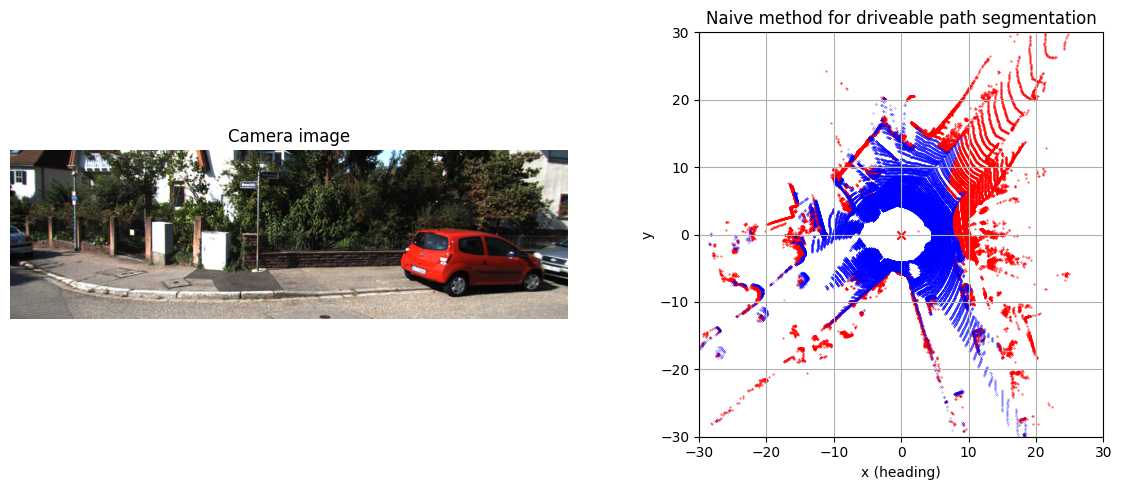

In [718]:
# Step 2- watch the results
# idx = 1 selects a single frame/sample from the dataset.
# We load the corresponding camera image (img_raw) and LiDAR point cloud (lidar_raw),
# then apply a simple filter to extract likely road/drivable LiDAR points (lidar_raw_road).
# Finally, we visualize: top = raw camera image, bottom = bird’s-eye LiDAR (x-y),
# where red = all LiDAR points, blue = road points, and (0,0) is the vehicle/sensor origin.

idx = 1
img_raw, lidar_raw = load_data(data, idx)
lidar_raw, lidar_raw_road = Filter_PC(lidar_raw)

### Visualize (side-by-side)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Left: camera image
axs[0].imshow(img_raw)
axs[0].set_title("Camera image")
axs[0].axis("off")

# Right: LiDAR top-down (x-y)
axs[1].scatter(lidar_raw[:, 0], lidar_raw[:, 1], c='r', marker='.', s=0.5)
axs[1].scatter(lidar_raw_road[:, 0], lidar_raw_road[:, 1], c='b', marker='.', s=0.1)
axs[1].scatter(0, 0, c='r', marker='x')

axs[1].set_title("Naive method for driveable path segmentation")
axs[1].axis('scaled')
axs[1].set_xlim(-30, 30)
axs[1].set_ylim(-30, 30)
axs[1].grid(True)
axs[1].set_xlabel("x (heading)")
axs[1].set_ylabel("y")

plt.tight_layout()
plt.show()


(B.1.b)	**Mode parameter calibration**. You can optimize the parameters for the scenario. The recommended hyperparameters are listed below, but they are flexible

The Occupancy Grid Map (OGM) in this tutorial is estimated with the procedure described in [3]. OGM is a grid-based (image-like) map where each of its cell/pixel contains probability of that cell occupied by any obstacle.

To update the OGM with the most recent measurement, the LiDAR points need to be converted to the similar grid format. This grid is called the scan grid (SG).

Take a look at the figure of a SG below. In the figure, the purple point is a sample of the LiDAR measurements. There are three conditions to fill the SG.
1. Black cells: The cells around the point (cells that are radially located at +-ALPHA and angularly located at +-BHETA from the point) are given probability = 0.8 which means that they are likely to be occupied.
2. White cells: The cells that are located between the origin/sensor and the measured point are given probability = 0.2 which means that they are likely to be free.
3. Gray cells: The other cells, including the ones behind the points, are given probability = 0.5 which means that we can't infer whether they are free or occupied.


<br>
<center><img src="https://raw.githubusercontent.com/orfaig/course_ex1/146218cc7ffabae80fe546b68ba03a6073fbefa2/figures/sg_gen.png" width=300px></center>
</br>


The efficient implementation of the SG creation is not straightforward. In this tutorial, we create the SG in spherical coordinate first. After the spherical SG is filled, then it is converted to cartesian coordinate.


There are several parameters that need to be defined:
- ALPHA [rad]- The radial resolution when converting LiDAR data to grid map in m (explained later).
- BHETA [rad] - The angular resolution when converting LiDAR data to grid map in radian (explained later) .
- RESOLUTION [m]- The resolution of the grid map in meter.
- MAX_RANGE [m]- The maximum active range of LiDAR points that will be converted to the grid map. This value should be equal to or less than the size of the occupancy map to ensure proper alignment and coverage.
- MAP_WIDTH [m]- Width of the map from side to side in meter.
- SPHERICAL2CARTESIAN_BIAS - An adjustment needed due to some errors when converting the spherical grid map to the cartesian grid map.

## Map Initialization

In [719]:
# these values can be changes
ALPHA = #TODO
BHETA = #TODO
RESOLUTION = #TODO
MAX_RANGE = #TODO
MAP_WIDTH = #TODO
PROBABILITY_SATURATION_BOTTOM = #TODO
PROBABILITY_SATURATION_UP = #TODO
PROB_HIT = #TODO
PROB_MISS = #TODO
SPHERICAL2CARTESIAN_BIAS = 6


The OGM is initialized with probability of all of its cells = 0.5

In [720]:
### Some derived parameters
# We discretize a square area of size MAP_WIDTH x MAP_WIDTH into grid cells of size RESOLUTION.
# The resulting occupancy grid map has MAP_SIZE_Y rows (y direction) and MAP_SIZE_X columns (x direction).

MAP_SIZE_X = #TODO   # number of cells along x
MAP_SIZE_Y = i#TODO  # number of cells along y (square map)

# Create the x and y coordinates (in meters) of each grid cell center, centered at (0,0).
xarr =#TODO
yarr = #TODO

# Build a 2D coordinate grid: MAP_XX holds x-coordinates, MAP_YY holds y-coordinates for every cell.
MAP_XX, MAP_YY = np.meshgrid(xarr, yarr)


### Initialize OGM (Occupancy Grid Map)
# Start with probability 0.5 everywhere (unknown: equally likely free or occupied).
ogm_time_0 = #TODO


Implementation of a grid on a single scan:

In [721]:
def generate_measurement_ogm(lidar_in, ogm_shape):
    """
    Generate a single-frame Occupancy Grid Map (OGM) from LiDAR input.

    Idea:
      1) Convert LiDAR (x,y) points into a POLAR grid (angle bins, range bins).
      2) In that polar grid, mark:
           - occupied cells (obstacles) with high probability (e.g. 0.8)
           - free cells (line-of-sight before the first obstacle) with low probability (e.g. 0.2)
      3) Convert the polar grid into a CARTESIAN occupancy map using cv2.warpPolar().

    Args:
        lidar_in (np.ndarray): filtered LiDAR point cloud, shape (N, 3) or (N, >=2)
                               uses x,y in meters.
        ogm_shape (tuple): desired output OGM shape (height, width)

    Returns:
        ogm_step (np.ndarray): 2D occupancy map (cartesian), values in [0,1]
                               0.5 = unknown, 0.2 = free, 0.8 = occupied.
    """

    # ----------------------------
    # 1) Convert (x,y) points to polar bins (angle bin, range bin)
    # ----------------------------
    # rphi_meas[:,0] = angle bin index
    # rphi_meas[:,1] = range bin index
    rphi_meas = np.zeros((lidar_in.shape[0], 2))

    # Range bin: distance in xy-plane divided by ALPHA (range resolution)
    rphi_meas[:, 1] = #TODO

    # Angle bin: arctan2(x, y) gives angle in [-pi, pi] (note the order x,y here),
    # shift to [0, 2pi], then divide by BHETA (angular resolution)
    rphi_meas[:, 0] = #TODO
    # Keep only unique (angle_bin, range_bin) pairs
    rphi_meas = #TODO

    # Clip bins to be within sensor / grid limits
    rphi_meas = #TODO
    rphi_meas = #TODO

    # ----------------------------
    # 2) Build the polar "scan grid"
    # ----------------------------
    sg_ang_bin = #TODO     # number of angle bins (rows)
    sg_rng_bin = #TODO     # number of range bins (cols)

    # Start as unknown probability 0.5 everywhere
    scan_grid = #TODO

    # Mark occupied cells (obstacles) as 0.8 (for example)
    rphi_int = rphi_meas.astype(np.int32)
    scan_grid[rphi_int[:, 0], rphi_int[:, 1]] = #TODO

    # Mark free cells as 0.2 (along each ray until the first obstacle)
    for ang in range(sg_ang_bin):
        # all obstacle ranges for this angle bin
        ang_arr = #TODO

        if len(ang_arr) == 0:
            # no obstacle detected on this ray => all ranges are free
            scan_grid[ang, :] =#TODO
        else:
            # free up to the closest obstacle
            min_range_idx = #TODO (hint- use min)
            scan_grid[ang, :min_range_idx] = #TODO

    # ----------------------------
    # 3) Convert polar scan_grid to cartesian OGM
    # ----------------------------
    # OpenCV expects size as (width, height)
    ogm_sz = (ogm_shape[1], ogm_shape[0])

    # Center of the output map (vehicle assumed at center)
    ogm_cen = (int(ogm_shape[1] / 2), int(ogm_shape[0] / 2))

    # Radius (in pixels) used by warpPolar:
    # MAX_RANGE/RESOLUTION converts meters to pixels; bias is an implementation tweak
    radius = (MAX_RANGE / RESOLUTION) + SPHERICAL2CARTESIAN_BIAS

    # WARP_INVERSE_MAP maps from polar -> cartesian
    ogm_step = #TODO  # hint use  scan_grid, ogm_sz, ogm_cen, radius,flags=cv2.WARP_INVERSE_MAP

    return ogm_step


## Display two single maps

In [722]:
# Return per-frame displacements (vfs, vls) and yaw
def load_vehicle_vel(data, idx):
    """.
    Parameters
    ----------
    data : dataset-like object
        Must contain:
            • data.oxts[idx].packet with fields: yaw, vf, vl
            • data.timestamps (list of datetime objects)
    idx : int
        Frame index.

    Returns
    -------
    (vfs, vls, yaw) : tuple of floats
        vfs – forward displacement [m] during this frame
        vls – left-lateral displacement [m] during this frame
        yaw – heading angle [rad] from OXTS packet
    """

    # Extract OXTS packet for this frame
    packet = #TODO

    # Vehicle yaw angle (radians)
    yaw = #TODO

    # Time difference from previous frame.
    # Frame 0 has no previous timestamp, so we approximate Δt = 0.1 s.
    delta_t = #TODO

    # Linear velocities from OXTS (m/s):
    #   vf – forward velocity, body-frame
    #   vl – lateral velocity, body-frame
    vf = #TODO
    vl = #TODO

    # Convert velocities to per-frame displacements [m]
    vfs = #TODO #[m]
    vls = #TODO  #[m]

    return vfs, vls, yaw


# Build odometry array for frames 1..N-1.
# For each frame, compute per-frame displacement and yaw.
# The result is an array of shape [num_frames-1, 3].
# odom = np.array([load_vehicle_vel(data, i) for i in range(1, len(data))])

In [723]:
def ogm_from_scan(data,ogm_time_init,idx):
  img_raw,lidar_raw = load_data(data,idx)
  lidar_raw,lidar_raw_road=Filter_PC(lidar_raw)
  ogm_time_current = generate_measurement_ogm(lidar_raw,ogm_time_init.shape)
  return ogm_time_current,img_raw


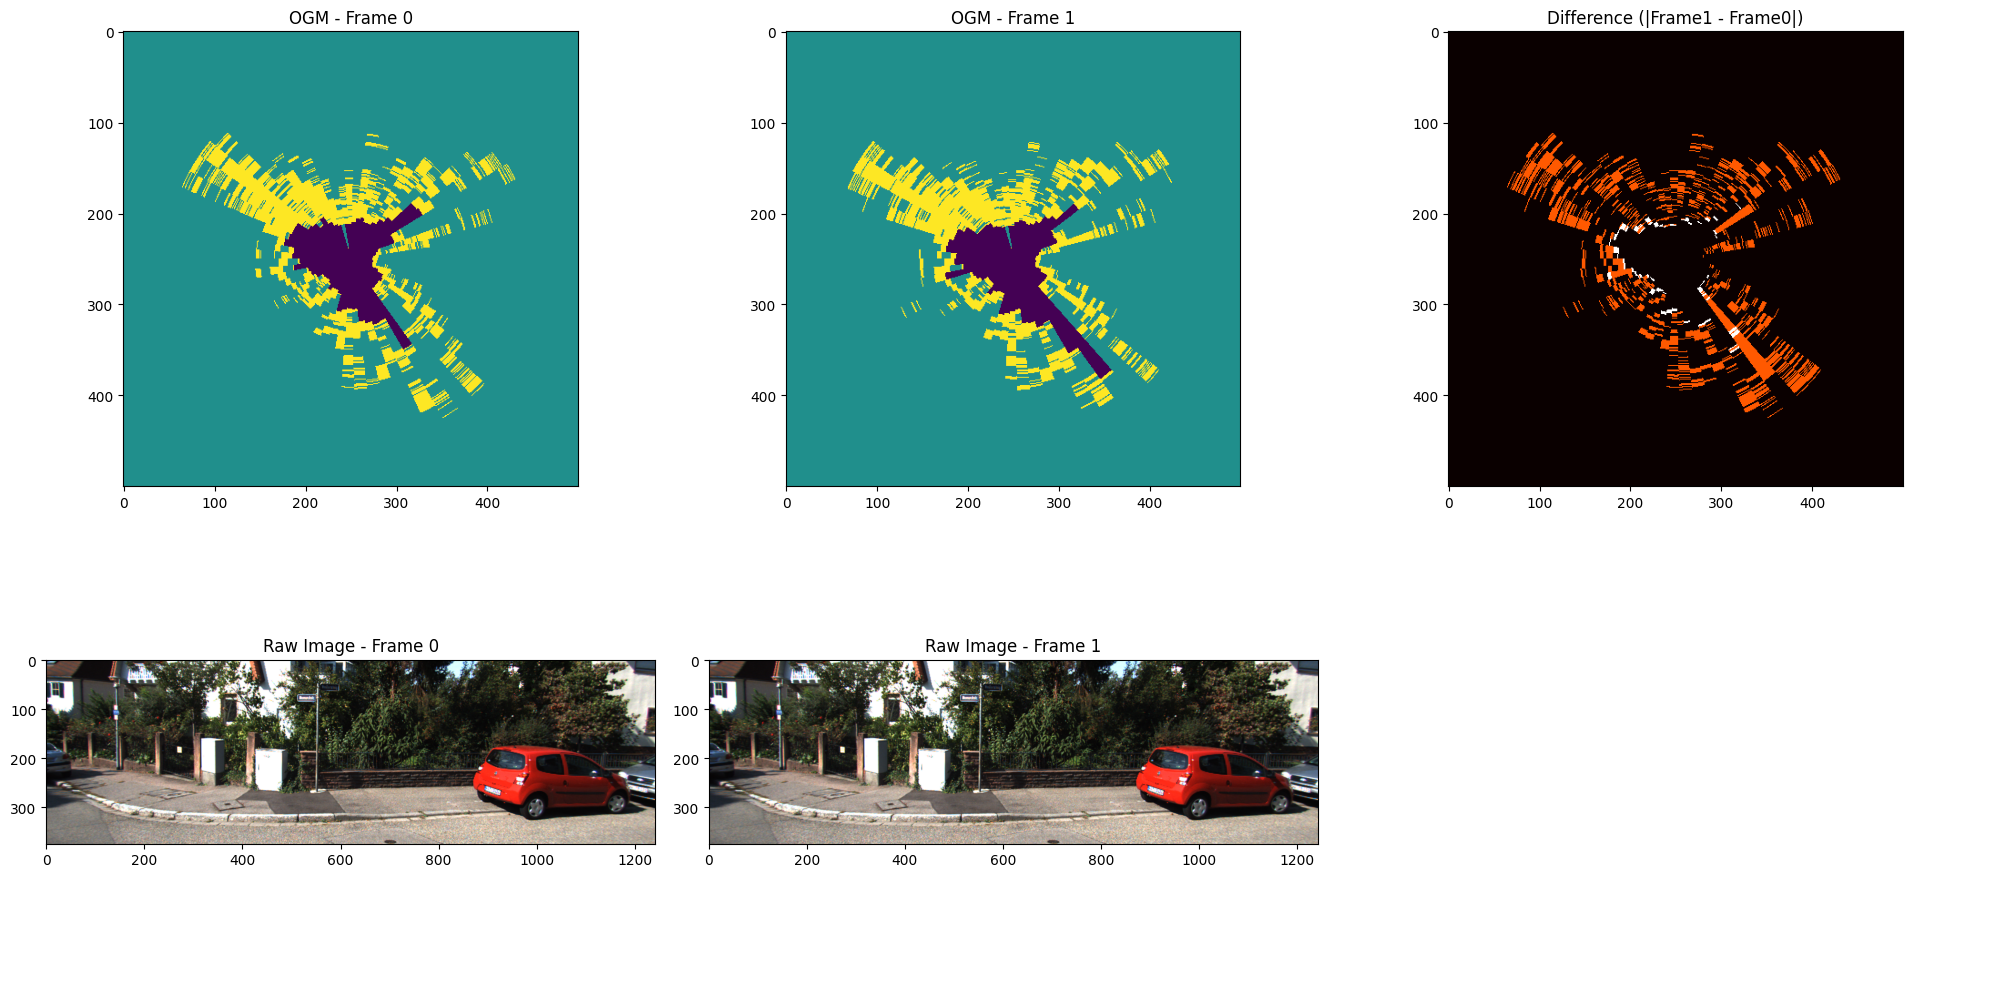

In [724]:
frame_index=0
frame_index_next=1

pose0 = load_vehicle_vel(data,frame_index)
pose1 = load_vehicle_vel(data,frame_index_next)

ogm_time_0,img_raw_0=ogm_from_scan(data,ogm_time_0,frame_index)
ogm_time_1,img_raw_1=ogm_from_scan(data,ogm_time_0,frame_index_next)



### Visualize
diff = np.abs(ogm_time_1 - ogm_time_0)  # difference map (absolute value)
fig, axs = plt.subplots(2, 3, figsize=(20, 10))  # 2 rows, 3 columns
# Frame 0
axs[0][0].imshow((ogm_time_0 * 255).astype(np.uint8))
axs[0][0].set_title("OGM - Frame 0")
# Frame 1
axs[0][1].imshow((ogm_time_1 * 255).astype(np.uint8))
axs[0][1].set_title("OGM - Frame 1")
# Difference
axs[0][2].imshow((diff * 255).astype(np.uint8), cmap='hot')
axs[0][2].set_title("Difference (|Frame1 - Frame0|)")
# Corresponding raw images
axs[1][0].imshow(img_raw)
axs[1][0].set_title("Raw Image - Frame 0")
axs[1][1].imshow(img_raw_1)
axs[1][1].set_title("Raw Image - Frame 1")
axs[1][2].axis('off')  # empty slot or you can put something else

plt.tight_layout()
plt.show()

(B.1.c)

## Try First Update

The OGM is updated by the recent scan grid using Bayesian update. According the derivation in the paper, if we initiate the OGM as empty grid, the $i$-th cell of OGM can be updated with this simple formula

\begin{align}
L_{i,t} = L_{i,t-1} + L^{SG}_{i,t-1}
\end{align}

$L_{i,t}$ is the [logit](https://en.wikipedia.org/wiki/Logit) of the $i$-th cell of the updated OGM.

$L_{i,t-1}$ is the logit of the $i$-th cell of the previous OGM.

$L^{SG}_{i,t-1}$ is the logit of the $i$-th cell of the scan grid that are generated from the latest LiDAR points.  

Then, the usable OGM can be found by calculating the inverse-logit of $L_{i,t}$

In [725]:
### Calculate the logit function
# Converts a probability map m (values in (0,1)) into log-odds:
#   logit(m) = log( m / (1 - m) )
# Log-odds are convenient because Bayesian updates become simple additions.
def logit(m):
  return #TODO

### Calculate the inverse logit function
# Converts log-odds back to probability:
#   inverse_logit(L) = exp(L) / (1 + exp(L))
# This returns values in (0,1).
def inverse_logit(m):
  return #TODO

### Update the prior OGM with the scan grid (new_ogm)

def update_ogm(prior_ogm, new_ogm):
  # Fuses the previous occupancy map (prior_ogm) with a new measurement map (new_ogm)
  # using log-odds addition:
  #   L_out = L_prior + L_new
  # Then converts back to probability.
  logit_map = #TODO
  out_ogm = #TODO
  #Finally, clamps probabilities to [0.02, 0.98] to avoid overconfidence and numeric issues.
  #TODO
  return out_ogm


##Shift the OGM!

Shift the OGM according to the next pose

In [726]:
# Shift the map according to the vehicle's pose change
# Goal: "move" (warp) the previous occupancy map so it stays aligned with the vehicle
# in the current frame. This compensates for the vehicle's translation and rotation
# between the previous pose (prev) and the current pose (curr).
#
# Inputs:
#   ogm  : occupancy grid map (2D), values typically in [0,1] where 0.5 = unknown
#   prev : previous vehicle pose/state  [x, y, yaw]  (units: meters, meters, radians)
#   curr : current  vehicle pose/state  [x, y, yaw]
#
# Output:
#   dst  : shifted/rotated occupancy map aligned to the current poses

def shift_pose_ogm(ogm,prev,curr):
  # ogm- occumpancy map
  # curr - current veloci
  # prev - previous meusrements
  ogm_o = ogm.copy()
  trs_m = np.array([[curr[0]],[curr[1]]]) # The forward distance is already accounted for by the current speed!
  delta_theta = (curr[2] - prev[2])
  delta = np.array([trs_m[1,0]/RESOLUTION,trs_m[0,0]/RESOLUTION,0])

  Translation = np.array([[1,0,-delta[0]],[0,1,delta[1]]]) # the forward direction in the image in negative direction in y axis (image)
  dst = cv2.warpAffine(ogm_o,Translation,(ogm_o.shape[1],ogm_o.shape[0]),borderValue=0.5)
  Rotation = cv2.getRotationMatrix2D((ogm_o.shape[1]/2+0.5,ogm_o.shape[0]/2+0.5),-delta_theta/np.pi *180 ,1) #Angle of Rotation. Angle is positive for anti-clockwise and negative for clockwise
  dst = cv2.warpAffine(dst,Rotation,(ogm_o.shape[1],ogm_o.shape[0]),borderValue=0.5)
  return dst

##Update next frame

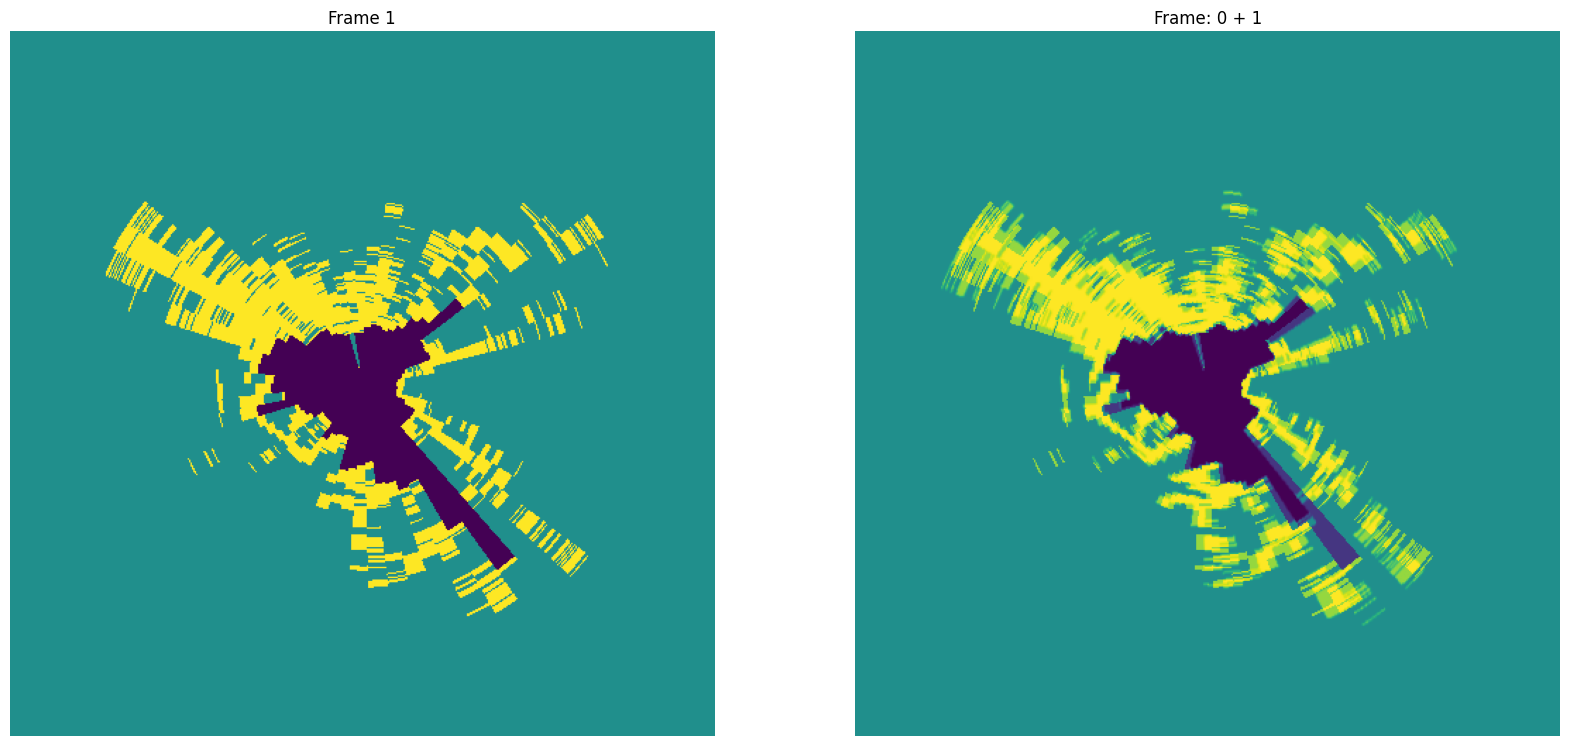

In [728]:
shift_ogm_time_0 =  #TODO hint use shift_pose_ogm,ogm_time_0,pose0,pose1
ogm_updated_1 = #TODO hint- use update_ogm,shift_ogm_time_0,ogm_time_1

### Visualize
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
axs = axs.ravel()

axs[0].imshow((ogm_time_1 * 255).astype(np.uint8))
axs[0].set_title(f"Frame {frame_index_next}")
axs[0].axis('off')

axs[1].imshow((ogm_updated_1 * 255).astype(np.uint8))
axs[1].set_title(f"Frame: {frame_index} + {frame_index_next}")
axs[1].axis('off')

plt.show()

## B.1.d

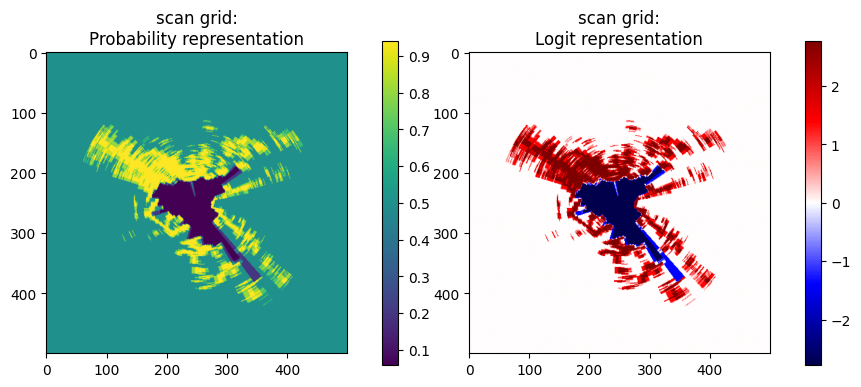

In [729]:
### Visualize Point cloud, probabilty and logit space
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Left subplot: probability representation
im0 = axs[0].imshow(ogm_updated_1)
axs[0].set_title("scan grid:\nProbability representation")
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.1)

# Right subplot: logit representation
im1 = axs[1].imshow(logit(ogm_updated_1), cmap='seismic')
axs[1].set_title("scan grid:\nLogit representation")
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.1)

plt.show()

##Robot mapping!

B.2  Implementation of a Probability Occupancy Grid over all the record

##  Helpfull functions


In [730]:
# ------------------------------------------------------------
# Helpful functions (used for LiDAR alignment and visualization)
#
# Goal:
# 1) Transform the LiDAR point cloud into the INS/IMU coordinate frame
#    using the provided calibration matrix (velo_to_imu_calibration).
# 2) Align (rotate) the point cloud using IMU orientation measurements
#    (roll, pitch) so points are expressed in a stabilized "ego" frame.
# ------------------------------------------------------------

def rotx(t):
    """Rotation matrix about the x-axis by angle t (radians)."""
    #TODO
def roty(t):
    """Rotation matrix about the y-axis by angle t (radians)."""
   #TODO
def rotz(t):
    """Rotation matrix about the z-axis by angle t (radians)."""
    #TODO

def transform_from_rot_trans(R, t):
    """
    Build a 4x4 homogeneous transformation matrix from:
      R: 3x3 rotation matrix
      t: 3x1 translation vector
    Output:
      T = [[R, t],
           [0, 0, 0, 1]]
    """
    R = R.reshape(3, 3)
    t = t.reshape(3, 1)
    return np.vstack((np.hstack([R, t]), [0, 0, 0, 1]))

def crop_center(img, crop_size=100):
    """
    Crop a square region of size (2*crop_size x 2*crop_size)
    from the image center.
    """
    h, w = img.shape[:2]
    cx, cy = w // 2, h // 2
    return img[cy - crop_size:cy + crop_size, cx - crop_size:cx + crop_size]

## Pre processing fucntion

In [731]:
def pre_processing(lidar_raw):
    """
    Pre_processing point cloud to an ego-stabilized frame.

    Steps:
      1) Filter point cloud (returns full filtered cloud + road subset).
      2) Convert to homogeneous coordinates and apply Velodyne->IMU calibration.
      3) Build rotation from IMU roll/pitch and apply it (stabilization).
      4) Return aligned xyz points and intermediate outputs.

    Returns:
      point_cloud_align           : (N,3) aligned xyz points
    """

    # Calibration: Velodyne -> IMU (4x4)
    # This matrix maps LiDAR points from the Velodyne sensor coordinate frame
    # into the IMU/INS coordinate frame.
    velo_to_imu_calibration = #TODO

    # 1) Filter point cloud (your function defines what "road" means)
    lidar_raw, lidar_raw_road = #TODO

    # 2) Translation of LiDAR to IMU location
    lidar_raw_h =#TODO # (N,4)
    lidar_raw_imu = #TODO                           # (4,N)

    # 3) Ego stabilization using IMU roll/pitch (use current frame orientation)
    Rx = rotx(-data.oxts[idx_frame].packet.roll)
    Ry = roty(-data.oxts[idx_frame].packet.pitch)
    R = Ry.dot(Rx)

    t = np.zeros((3, 1))
    ego_T = transform_from_rot_trans(R, t)

    lidar_aligned = ego_T.dot(lidar_raw_imu)
    lidar_aligned = lidar_aligned.T
    # 4) Extract xyz (meters)
    x_points = lidar_aligned[:, 0]
    y_points = lidar_aligned[:, 1]
    z_points = lidar_aligned[:, 2]
    point_cloud_align = np.vstack((x_points, y_points, z_points)).T

    return point_cloud_align,lidar_aligned,lidar_raw_road


SyntaxError: invalid syntax (315450637.py, line 18)

##Repeat the occupancy map process over all your scans/frames!!#

In [ ]:
# ------------------------------------------------------------
# Helper: convert saved PNG frames into a video (10 FPS, MPEG-4 in .mp4 container)
# ------------------------------------------------------------
def frames_to_video(frames_folder, out_video_path, fps=10, pattern="occupancy_map_frame_*.png"):
    """
    Reads PNG frames from frames_folder and saves them as a video.

    Args:
        frames_folder (str): folder containing frame images
        out_video_path (str): output video path (recommended: .mp4)
        fps (int): frames per second
        pattern (str): filename pattern for frames

    Returns:
        out_video_path (str)
    """
    frame_paths = sorted(glob.glob(os.path.join(frames_folder, pattern)))
    if len(frame_paths) == 0:
        raise FileNotFoundError("No frames found. Check the folder and pattern.")

    # Read first frame to get video size
    first = cv2.imread(frame_paths[0])
    if first is None:
        raise ValueError(f"Could not read first frame: {frame_paths[0]}")
    h, w = first.shape[:2]

    # MPEG-4 codec (works well in Colab). Output is an MPEG-4 video in an .mp4 file.
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(out_video_path, fourcc, fps, (w, h))

    for p in frame_paths:
        img = cv2.imread(p)
        if img is None:
            continue
        # Ensure consistent size (important for VideoWriter)
        if img.shape[0] != h or img.shape[1] != w:
            img = cv2.resize(img, (w, h))
        writer.write(img)

    writer.release()
    return out_video_path


In [ ]:
fig_vid_path = os.getcwd() + "/_naive_method_example_2026" + drive
if not os.path.exists(fig_vid_path):
    os.makedirs(fig_vid_path)

In [ ]:
# Initialize Occupancy Grid Map (OGM) and state
Occupancy_map = np.full((MAP_SIZE_Y, MAP_SIZE_X), 0.5, dtype=np.float32)
pose_prev = (0, 0, 0)
SHOW_FIG = True

for idx_frame in range(len(data)):
    # 1) Load data for this frame
    img_raw, lidar_raw = #TODO: use load_data
    pose = #TODO: use load_vehicle_vel

    # 2) Align LiDAR into ego-stabilized frame + get road subset
    point_cloud_align, lidar_raw, lidar_road = #TODO: use pre_processing

    # 3) Occupancy map update pipeline
    # a) shift previous map according to vehicle motion
    shifted_ogm = #TODO: use shift_pose_ogm
    # b) create measurement OGM from current LiDAR
    ogm_step = #TODO: use generate_measurement_ogm
    # c) fuse maps (Bayesian update)
    Occupancy_map = #TODO: use update_ogm

    pose_prev = pose

    # 4) Visualization (2x2 Diagnostic Plot)
    fig, axs = plt.subplots(2, 2, figsize=(15, 12))

    axs[0, 0].imshow(img_raw)
    axs[0, 0].set_title(f"Camera (Frame {idx_frame:03d})")

    axs[0, 1].scatter(-point_cloud_align[:, 1], point_cloud_align[:, 0], c="r", s=0.1)
    axs[0, 1].scatter(-lidar_road[:, 1], lidar_road[:, 0], c="b", s=0.1)
    axs[0, 1].set_xlim(-40, 40); axs[0, 1].set_ylim(-40, 40)
    axs[0, 1].set_title("LiDAR Road Segmentation")

    axs[1, 0].imshow(crop_center(ogm_step, 400))
    axs[1, 0].set_title("Current Hitmap")

    axs[1, 1].imshow(crop_center(Occupancy_map, 400))
    axs[1, 1].set_title("Fused Occupancy Map")

    # 5) Save and finalize frame
    frame_path = os.path.join(fig_vid_path, f"occupancy_map_frame_{idx_frame:03d}.png")
    fig.savefig(frame_path, dpi=100)

    if SHOW_FIG: plt.show()
    plt.close(fig)

# --- Create video from saved frames ---
out_video = os.path.join(fig_vid_path, f"occupancy_map_video_{drive}.mp4")
frames_to_video(fig_vid_path, out_video, fps=10)

In [ ]:
  #Very good! well done!

  #This section display the first 6 occupancy images for review and evaluation.
  #Verify that the generated maps are valid and align with the concepts taught in class.
  num_maps = 6
  rows = (num_maps + 1) // 2  # Ensure a 2-column layout
  cols = 2

  fig, axs = plt.subplots(rows, cols, figsize=(15, rows * 6))
  axs = axs.flatten()  # Flatten axes array for easier iteration

  for idx, ax in enumerate(axs):
      if idx < num_maps:
          ax.imshow(occmap_history[idx])
          ax.scatter(400,400,c='r',marker='x')
          ax.set_title(f"Occupancy Map At Frame Number={idx + 1:03}")
          ax.axis('scaled')
      else:
          ax.axis('off')  # Turn off axes for unused slots

plt.savefig(fig_dir_path + "/" + "OccMap_history.png")

(B.2.g)

Apply threshoulds on the occupancy map:
The segmented maps should describe 3 types of cells: free, occluded and unknown.


In [ ]:
# Thresholds used to convert a probabilistic occupancy map into a segmented (discrete) map.
# - If the occupancy probability is LOW enough, we label the cell as FREE space.
# - If the occupancy probability is HIGH enough, we label the cell as OCCUPIED (obstacle).
# - Values in-between remain UNKNOWN/UNCERTAIN (not enough evidence).
threshold_for_free =      # TODO: tune based on your sensor/model
threshold_for_Occupied =  # TODO: tune based on your sensor/model

### Visualize Segmented_occupancy_map
# We display 3 maps side-by-side:
# (1) ogm_step: measurement map from the current LiDAR scan (single frame)
# (2) Occupancy_map: fused occupancy probability map accumulated over frames
# (3) Occupancy_map_final: segmented map (free / unknown / occupied)
fig, axs = plt.subplots(1, 3, figsize=(20, 10))

# 1) Measurement map (single frame)
img0 = axs[0].imshow(ogm_step)
fig.colorbar(img0, ax=axs[0], fraction=0.046, pad=0.1)
axs[0].set_title("scan grid")

# 2) Fused occupancy probability map
img1 = axs[1].imshow(Occupancy_map)
fig.colorbar(img1, ax=axs[1], fraction=0.046, pad=0.1)
axs[1].set_title("Occupancy_map")
axs[1].axis('scaled')

# 3) Segmented/discrete map
# Initialize all cells as UNKNOWN/UNCERTAIN (same shape as Occupancy_map)
Occupancy_map_final = np.ones_like(Occupancy_map, dtype=float) * 0.5

# Mark FREE cells (low probability of being occupied)
Occupancy_map_final[Occupancy_map < threshold_for_free] = 0

# Mark OCCUPIED cells (high probability of being occupied)
Occupancy_map_final[Occupancy_map > threshold_for_Occupied] = 1

img2 = axs[2].imshow(Occupancy_map_final, cmap='PRGn')
fig.colorbar(img2, ax=axs[2], fraction=0.046, pad=0.1)
axs[2].set_title("Segmented_occupancy_map")

plt.show()

Example
<br>
<center><img src="https://raw.githubusercontent.com/orfaig/course_ex1/146218cc7ffabae80fe546b68ba03a6073fbefa2/figures/segmented_map.png" width=1200px></center>
</br>

# Part C: Sensor fusion and Road segemenation

The goal of the perception system is to extract the information about the round where the vehicle is operating on. This road information will be used to filter out LiDAR points that hit the road so that it can be used for mapping purpose. To extract the information about where the road is, we use deep learning-based image segmentation technique that will be applied to the camera image.

## Get Callibration Data

Two callibrated parameters that we need:
- LiDAR to camera extrinsic matrix - The matrix (4x4) that will be used to transform the LiDAR points to the camera 3D coordinate frame.
-  Camera intrinsic matrix - The mastrix (3x3) that will be used to calculate the coordinate of pixels that representat 3D points in camera coordinate.

The calibrated parameters are already provided in the dataset. For details, please take a look at [this explanation](https://www.mathworks.com/help/vision/ug/camera-calibration.html) from Mathworks.

In [ ]:
### Retrieve the provided calibration data (cam2)
lidar2cam_extrinsic =  #TODO
camera_intrinsic =  #TODO

print('Lidar to camera extrinsic matrix: ')
print(lidar2cam_extrinsic)
print()
print('Camera intrinsic matrix: ')
print(camera_intrinsic)

## Load Camera and LiDAR Data

Coordinate system of
- Camera = x: right, y: down, z: forward
- LiDAR = x: forward, y: left, z: up

In this tutorial, camera coordinate system is used. Therefore, the LiDAR points need to be transformed to the camera coordinate frame. Use the LiDAR to camera extrinsic matrix!

The extrinsic matrix can be written as $\begin{bmatrix} R|t \end{bmatrix}$, a combinarion of a rotation matrix $R$ and a translation vector $t$. Given that the point in LiDAR coordinate is $(X_L,Y_L,Z_L)$, its coordinate in camera 3D frame, $(X_C,Y_C,Z_C)$ is

\begin{align}
\begin{bmatrix}
X_C \\
Y_C \\
Z_C \\
1 \\
\end{bmatrix}=
\begin{bmatrix} R|t \end{bmatrix}
\begin{bmatrix}
X_L \\
Y_L \\
Z_L \\
1 \\
\end{bmatrix}
\end{align}



In [ ]:
def filter_PC_cam(lidar_raw):
  #use the lower 32 layers of the 64-layer LiDAR
  lidar_raw = #TODO
  dist =
  #filter point cloud within the car radius
  lidar_raw = #TODO
  return lidar_raw

### Transform the LiDAR points into camera coordinate
def transform_velo_to_cam(lidar_points,extrinsic_matrix):
  inp = lidar_points.copy()
  #TODO
  return inp[:,:3]

### Transform the LiDAR points from camera coordinate to velodyne coordinate
def transform_cam_to_velo(cam_points, extrinsic_matrix):
  # invert the transform
  T_velo_cam =  #TODO

  # make homogeneous
  pts = cam_points.copy()
  pts_h = np.concatenate((pts, np.ones((pts.shape[0], 1))), axis=1)

  # transform back
  pts_velo_h = (T_velo_cam @ pts_h.T).T

  return pts_velo_h[:, :3]


def segment_by_height_cam(points_xyz, sensor_height=1.73, height_threshold=0.5):
    """
    Segment points into obstacles and ground based on height in Camera coordinates.
    Hint: In KITTI Camera, Y-axis points DOWN.
    """
    # TODO: Identify the correct index [0, 1, or 2] for the Y-coordinate
    height_ag = sensor_height - points_xyz[:, #TODO]

    mask_obstacle = height_ag > height_threshold
    mask_ground   = height_ag < height_threshold
    return mask_obstacle, mask_ground

def segment_by_height_velo(points_xyz, sensor_height=1.73, height_threshold=0.3):
    """
    Segment points into obstacles and ground based on height in Velodyne (LiDAR) coordinates.
    Hint: In KITTI Velodyne, Z-axis points UP.
    """
    # TODO: Identify the correct index [0, 1, or 2] for the Z-coordinate
    height_ag = sensor_height + points_xyz[:, #TODO]

    mask_obstacle = height_ag > height_threshold
    mask_ground   = height_ag < height_threshold
    return mask_obstacle, mask_ground


C.1 *LiDAR–Camera* Coordinate Transformation and Height-Based Segmentation

In [ ]:
# ------------------------------------------------------------
# Main code: Display obstacle vs road using camera coordinates
# ------------------------------------------------------------

idx=0
# idx1=1
# 1) Filter LiDAR (remove vehicle/self points + any dataset-specific cleanup)
img_raw,lidar_raw = load_data(data,idx)
lidar_raw= #TODO filter_PC_cam
lidar_raw_cam = #TODO use  transform_velo_to_cam


index_obs, index_free =  #TODO use segment_by_height_cam
fig,axs = plt.subplots(1,2,figsize=(15,12))
axs[0].imshow(img_raw)

axs[1].scatter(lidar_raw_cam[index_obs,0],lidar_raw_cam[index_obs,2],c='r',marker='.',s=0.1)
axs[1].scatter(lidar_raw_cam[index_free,0],lidar_raw_cam[index_free,2],c='b',marker='.',s=0.1)
axs[1].scatter(0,0,c='r',marker='x')
axs[1].set_title("point cloud includes the road!")
axs[1].axis('scaled')
axs[1].set_xlabel("X_cam (right)")
axs[1].set_ylabel("Z_cam (forward)")
axs[1].set_title("LiDAR in camera frame (top-down X–Z)")
axs[1].grid(True, linestyle='--', linewidth=0.5)
plt.show()



In [ ]:
# ------------------------------------------------------------
# Main code: Display obstacle vs road using camera coordinates back to velodyne
# ------------------------------------------------------------

idx=0
# 1) Filter LiDAR (remove vehicle/self points + any dataset-specific cleanup)
img_raw,lidar_raw = load_data(data,idx)
lidar_raw=filter_PC_cam(lidar_raw)
lidar_raw_cam = #TODO use transform_velo_to_cam
lidar_raw_velo = #TODO use transform_cam_to_velo

index_obs, index_free = #TODO use segment_by_height_velo
fig,axs = plt.subplots(1,2,figsize=(15,12))
axs[0].imshow(img_raw)

axs[1].scatter(lidar_raw_velo[index_obs,0],lidar_raw_velo[index_obs,1],c='r',marker='.',s=0.1)
axs[1].scatter(lidar_raw_velo[index_free,0],lidar_raw_velo[index_free,1],c='b',marker='.',s=0.1)
axs[1].scatter(0,0,c='r',marker='x')
axs[1].set_title("point cloud includes the road!")
axs[1].axis('scaled')
axs[1].set_xlabel("X_velo (forward)")
axs[1].set_ylabel("Y_velo (left)")
axs[1].set_title("LiDAR in Velodyne frame (top-down X–Y)")
axs[1].grid(True, linestyle='--', linewidth=0.5)
plt.show()

## Project the LiDAR Points to the Camera

To transfer the road information from image to LiDAR, we need to project the LiDAR points to the camera image. Use the camera intrinsic matrix!

The camera intrinsic matrix is denoted as $K$. The coordinate of pixel, $(u,v)$, that represents a point in 3D space, $(X_C,Y_C,Z_C)$, in image frame can be calculated with

\begin{align}
\begin{bmatrix}
u\times w \\
v\times w \\
w \\
\end{bmatrix}=
K
\begin{bmatrix}
X_C \\
Y_C \\
Z_C \\
\end{bmatrix}
\end{align}

<br>
<center><img src="https://docs.opencv.org/4.5.0/pinhole_camera_model.png" width=400px></center>
</br>

Sumber gambar: [OpenCV Docs](https://docs.opencv.org/3.4/d9/d0c/group__calib3d.html)

(C.1.b)

In [ ]:
def project_points_to_image(lidar_raw_cam, camera_intrinsic, img_raw_size):
    """
    Projects 3D points cloud in camera coordinates to 2D image coordinates.

    Args:
        lidar_raw_cam (Nx3): Points in camera frame (X-right, Y-down, Z-forward)
        camera_intrinsic (3x3): Camera intrinsic matrix (K)
        img_raw_size (tuple): Image size in the form (height, width, channels)

    Returns:
        lidar_2d (Nx2): 2D image coordinates (u, v)
        lidar_in_cam_img (Nx3): 3D camera-frame points that fall inside the image
    """
    # 1. Filter out points behind the camera (z <= 0)
    mask_forward = #TODO
    lidar_in_cam = #TODO

    # 2. Convert to homogeneous and apply K
    pixels_hom = #TODO  #  hint-1 (use camera_intrinsic )

    # 2b. Normalize to get pixel coordinates (u = x/z, v = y/z)
    lidar_2d = pixels_hom[:, :2] / lidar_in_cam[:, 2:3]  # Nx2
    lidar_2d = lidar_2d.astype(int)

    # 3. Filter out points outside image boundaries
    height, width = img_raw_size[:2]
    mask_u = (lidar_2d[:, 0] >= 0) & (lidar_2d[:, 0] < width)
    mask_v = (lidar_2d[:, 1] >= 0) & (lidar_2d[:, 1] < height)
    mask = mask_u & mask_v

    lidar_2d_pixels = lidar_2d[mask]
    lidar_in_cam_img_3D = lidar_in_cam[mask]

    return lidar_2d_pixels, lidar_in_cam_img_3D


img_raw_size = img_raw.shape

lidar_2d_pixels,lidar_in_cam_img_3D = #TODO use project_points_to_image

### Visualize
print(f'Original image size: {img_raw.shape}')

img = img_raw.copy()
axs = 2
axs_log = np.log(lidar_in_cam_img_3D[:,axs]-np.min(lidar_in_cam_img_3D[:,axs])+1)
max_axs = np.max(axs_log)
for pt,z in zip(lidar_2d_pixels,axs_log):
    color_z = z*255/max_axs
    c = (color_z,0,0)
    cv2.circle(img,tuple(pt[:2].astype(int)),1,c,-1)

fig, axs = plt.subplots(1, 1, figsize=(15, 7))
axs.imshow(img)
axs.set_aspect('equal')
axs.axis('scaled')
plt.show()

(C.2)

## Image Cropping

The deep learning model (DeepLab v3+) was trained with cropped images from KITTI dataset with ratio 4:3 (W:H), which was resized further to 513 x 513 images. It will work better if we use the same size of images.

Parameter:
- CROP_RH - The height ratio of target image size
- CROP_RW - The width ratio of target image size

In [ ]:
### Function to crop the image according to the target size ratio
### The image will be cropped at the center
def center_crop_to_aspect_with_lidar(img_in, lidar_2d_in, lidar_in_cam_img, rh, rw):
    lidar_2d = lidar_2d_in.copy()
    lidar_in_cam_img = lidar_in_cam_img.copy()
    img = img_in.copy()

    ### Crop the image
    dim_ori = np.array(img.shape)
    cent = (dim_ori / 2).astype(int)

    if dim_ori[0] / dim_ori[1] == rh / rw:
        crop_img = img
        cH2 = dim_ori[0]
        cW2 = dim_ori[1]

    # If Height <= Width
    elif dim_ori[0] <= dim_ori[1]:
        cH2 = dim_ori[0]
        cW2 = cH2 * rw / rh
        cW = int(cW2 / 2)
        crop_img = img[:, cent[1] - cW:cent[1] + cW + 1]

    # If Height > Width
    else:
        cW2 = dim_ori[1]
        cH2 = cW2 * rh / rw
        cH = int(cH2 / 2)
        crop_img = img[cent[0] - cH:cent[0] + cH + 1, :]

    ### Filter out LiDAR points outside cropped image
    cW = cW2 / 2  # horizontal half-width
    cH = cH2 / 2  # vertical half-height
    centH = cent[0]
    centW = cent[1]

    # Fill in the missing TODOs
    # maskH = #TODO (hint horizontal: lidar_2d[:,1])
    # maskW = #TODO (hint vertical: lidar_2d[:,0])
    mask = np.logical_and(maskH, maskW)

    lidar_2d_crop = lidar_2d[mask, :]
    lidar_in_cam_img_crop = lidar_in_cam_img[mask, :]

    # Adjust LiDAR 2D points to new origin (top-left of crop)
    cent = np.array((centW - cW, centH - cH)).reshape((1, 2))
    lidar_2d_crop = lidar_2d_crop - cent

    return crop_img, lidar_2d_crop.astype(int), lidar_in_cam_img_crop

In [ ]:
### Cropped image's size ratio
CROP_RH = 3  # Height ratio
CROP_RW = 4  # Width ratio

crop_img,  lidar_2d_crop,  lidar_in_cam_img_crop  = #TODO use  center_crop_to_aspect_with_lidar

# --------------------------------------------------
### Visualize
img = crop_img.copy()
axs = 2
axs_log = np.log(lidar_in_cam_img_crop[:, axs] - np.min(lidar_in_cam_img_crop[:, axs]) + 1)
max_axs = np.max(axs_log)
for pt, z in zip(lidar_2d_crop, axs_log):
    color_z = z * 255 / max_axs
    c = (color_z, 0, 0)
    cv2.circle(img, tuple(pt[:2].astype(int)), 1, c, -1)

fig, axs = plt.subplots( figsize=(5, 7))
axs.imshow(img)
axs.set_title(f"Projected LiDAR on Cropped Image - Frame {idx}")
plt.tight_layout()
plt.show()

(C.3)

## Road Segmentation

Process the camera image with image segmentation-based deep learning method to get regions that correspond to the road. Specifically, we use DeepLab v3+ model that has been trained before with KITTI dataset. The model has been trained on image with size 513 x 513. Thus, the input image need to be resized first before being processed by the model. [Read this article](https://rockyshikoku.medium.com/train-deeplab-v3-with-your-own-dataset-13f2af958a75) if you want to know how to train your own DeepLab v3+ model.

Parameters:
- DEEPLAB_MODEL_PATH - Path to the model protobuff (.pb) file
- DEEPLAB_INPUT_SIZE - Input size of the model

Now, by projecting the LiDAR points to the segmented image, we can know which points that correspond to the road.

In [ ]:
### Function to process the image with DeepLabv3+
def deeplabv3_road_segmentation(img_in, sess, target_size=513, probability_threshold=0.5):
    INPUT_TENSOR_NAME = 'ImageTensor:0'
    PROB_TENSOR_NAME = 'SemanticProbabilities:0'
    INPUT_SIZE = target_size

    image = img_in.copy()
    sz = image.shape
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Resize input image to target size
    if INPUT_SIZE == 0:
        resized_image = image.copy()
    else:
        resized_image = cv2.resize(image, (INPUT_SIZE, INPUT_SIZE))

    # Run deep learning inference
    batch_seg_map = sess.run(
        PROB_TENSOR_NAME,
        feed_dict={INPUT_TENSOR_NAME: [np.asarray(resized_image)]}
    )
    seg_map = (batch_seg_map[0][:, :, 1] * 255).astype(int)
    prob = np.array(seg_map, dtype=np.uint8)
    prob = cv2.resize(prob, (sz[1], sz[0]))

    # Create binary prediction
    pred = prob.copy()
    msk_bin = prob >= (probability_threshold * 255)
    pred[msk_bin] = 1
    pred[np.logical_not(msk_bin)] = 0

    # Keep largest connected road region only
    #   # Ignore regions that are separated from the main road
    # This can reduce the amount of false detection
    # hint- use cv2.connectedComponents
    #   _,segm_reg = #TODO
    segm_reg = segm_reg.astype(float)
    segm_reg[segm_reg == 0] = np.nan

    modes, _ = stats.mode(segm_reg.flatten(), axis=None, nan_policy="omit")
    mode = np.atleast_1d(modes)[0]
    pred[segm_reg != mode] = 0

    return prob, (pred * 255).astype(np.uint8)



### Load the model
DEEPLAB_MODEL_PATH = '/content/Course_0510_7951/pretrained/deeplab_model.pb'


with open(DEEPLAB_MODEL_PATH, "rb") as f:
    graph_def = tf.compat.v1.GraphDef.FromString(f.read())
graph = tf.Graph()
with graph.as_default():
    tf.import_graph_def(graph_def=graph_def, name="")
sess = tf.compat.v1.Session(graph=graph)

DEEPLAB_INPUT_SIZE = 513
segm_prob,segm_pred = #TODO use deeplabv3_road_segmentation


# Display poiny cloud of raw on image
### Visualize
segm_3ch = crop_img.copy()
for pt in lidar_2d_crop:
  pt = pt.astype(int)
  if segm_pred[pt[1],pt[0]] == 0:
    continue
  c = (255,0,0)
  cv2.circle(segm_3ch,tuple(pt[:2]),1,c,-1)

fig,axs = plt.subplots(figsize=(10,7))
axs.imshow(segm_3ch)
plt.show()




In [ ]:
# c.4
# Display road segmentation overlay on image
img_rgb = cv2.cvtColor(segm_pred, cv2.COLOR_GRAY2BGR)
img_rgb[segm_pred > 0, 0] = 0
img_rgb[segm_pred > 0, 1] = 20
img_rgb[segm_pred > 0, 2] = 255

# Blend segmentation with original cropped image
overlay_image =#TODO (hint-use  cv2.addWeighted function, crop img and img_rgb ) cv2.addWeighted(crop_img,0.9,img_rgb,0.8,1)

fig, axs = plt.subplots(1, 1, figsize=(6, 6))
axs.imshow(overlay_image)
axs.set_title("Road Segmentation Overlay")
axs.axis('off')
plt.show()

## C.4 LiDAR Road Filter

The road points set that are obtained from the previous step may contain false detection and obviously only contains point that are inside the camera field of view. We also need to detect road points that are outside this set!

To do this, fit a plane model (which will represent the road model) $Ax+By+Cz=1$ to the current road points. Any points that are outside the camera field of view and located near the road plane model can be also regarded as road points. RANSAC algorithm is applied when fitting the model to reduce the influence of outliers. Visit this [Wikipedia page](https://en.wikipedia.org/wiki/Random_sample_consensus) for more information about RANSAC.

Parameter:
- ROAD_HEIGHT_THRESHOLD - The maximum distance (in height axis) between a point to the road model to be considered as road point.

In [ ]:
#### Get the plane model from the road points
def get_road_model_ransac(img_pred, lidar_in_cam_img_crop, lidar_2d_crop):
    # inputs: lidar_in_cam_img_crop - point cloud in camera coordinates
    #          lidar_2d_crop - corresponding 2D projection into image
    #          img_pred - segmentation mask (binary 0/255)

    h, w = img_pred.shape
    lidar_in_road = []

    # Go point-by-point, checking image pixel labels
    for pt2d, pt3d in zip(lidar_2d_crop, lidar_in_cam_img_crop):
        u, v = pt2d[0], pt2d[1]
        if 0 <= u < w and 0 <= v < h:
            if img_pred[v, u] == 255:
                lidar_in_road.append(pt3d)

    lidar_in_road = np.array(lidar_in_road)

    Mininal_set_of_point = 10  # optional, calibrate as needed

    if lidar_in_road.shape[0] < Mininal_set_of_point:
        status = 0
        road_model = None
    else:
        X = lidar_in_road[:, [0, 2]]  # x and z
        y = lidar_in_road[:, 1]      # y (height)
        # Estimate the road model
        # (hint- use RANSACRegressor function, lidar_in_road and Mininal_set_of_point )
        # TODO
        status = 1

    return road_model, status

In [ ]:

def split_points_by_road_plane(road_model, lidar_raw_cam, threshold=0.5):
    """
    Classifies LiDAR points as road or non-road based on distance from fitted road plane.

    Args:
        road_model: Trained RANSACRegressor model (plane fit)
        lidar_raw_cam (Nx3): LiDAR points in the **camera coordinate system** (X: right, Y: down, Z: forward)
        threshold (float): Max vertical distance (in meters) from the plane to consider a point as road

    Returns:
        lidar_nonroad (Mx3): Points belonging to obstacles
        lidar_road (Kx3): Points belonging to the road surface
    """

    # TODO: Extract the (X,Z) coordinates used as input for the plane model
    # Hint: In KITTI camera coordinates, the road plane is defined by X and Z
    x =

    # TODO: Extract the true Y coordinates (vertical axis/height)
    y_true =

    # TODO: Predict the expected Y values for each (X,Z) point using the road_model
    y_pred =

    # TODO: Calculate the absolute distance (delta_y) between the true Y and predicted Y
    # Hint: Use np.absolute().flatten()
    delta_y =

    # TODO: Determine which points are far from the road (non-road) using the threshold
    is_not_road =

    # Separate points based on the boolean mask
    lidar_nonroad = lidar_raw_cam[is_not_road, :]
    lidar_road = lidar_raw_cam[~is_not_road, :]

    return lidar_nonroad, lidar_road


In [ ]:

def get_road_inroad_lidar(segm_pred, lidar_in_cam_img_crop, lidar_2d_crop, lidar_raw_cam, lidar2cam_extrinsic, road_height_threshold):
    """
    Estimate a road plane model using image segmentation + LiDAR points in the cropped image,
    then split the full (camera-frame) LiDAR cloud into road / non-road by distance to that plane,
    and finally convert both sets back to Velodyne (LiDAR) coordinates for downstream use/visualization.
    """

    # 1) Fit road plane model using RANSAC (Segmentation + LiDAR)
    road_model, status = #TODO

    # 2) Split full camera-frame LiDAR cloud by distance to the plane
    lidar_nonroad, lidar_road  = #TODO use split_points_by_road_plane

    # 3) Convert points from camera frame back to velodyne (LiDAR) frame
    lidar_nonroad_velo = transform_cam_to_velo(lidar_nonroad, lidar2cam_extrinsic)
    lidar_road_velo = transform_cam_to_velo(lidar_road, lidar2cam_extrinsic)

    return lidar_nonroad_velo, lidar_road_velo

In [ ]:
# -----------------------------
# Pipeline usage example
# -----------------------------

# Load raw image and raw LiDAR (velodyne frame)
img_raw, lidar_raw = load_data(data, idx)

# Filter LiDAR points (e.g., remove invalid points, limit FOV, range filtering, etc.)
lidar_raw = filter_PC_cam(lidar_raw)

# Image size needed for projection bounds / validity checks
img_raw_size = img_raw.shape

# Transform LiDAR points from velodyne frame -> camera frame (for projection and plane splitting)
lidar_raw_cam = transform_velo_to_cam(lidar_raw, lidar2cam_extrinsic)

# Project camera-frame LiDAR points to image pixels:
# - lidar_2d_pixels: (N,2) pixel coordinates
# - lidar_in_cam_img_3D: (N,3) the subset/representation aligned with the projection output
lidar_2d_pixels, lidar_in_cam_img_3D = project_points_to_image(
    lidar_raw_cam, camera_intrinsic, img_raw_size
)

# Crop the image to a desired aspect ratio and keep only LiDAR points that fall inside the crop
crop_img, lidar_2d_pixels_crop, lidar_in_cam_img_crop = center_crop_to_aspect_with_lidar(
    img_raw,
    lidar_2d_pixels,
    lidar_in_cam_img_3D,
    CROP_RH,
    CROP_RW,
)

# Run road segmentation on the cropped image
segm_prob, segm_pred = deeplabv3_road_segmentation(
    crop_img, sess, DEEPLAB_INPUT_SIZE, 0.5
)

# -----------------------------
# Visualization: compare two thresholds
# -----------------------------

fig, axs = plt.subplots(1, 2, figsize=(15, 8))

# # Frame 0
road_height_threshold = #TODO
lidar_nonroad_velo,lidar_road_velo= get_road_inroad_lidar(segm_pred,lidar_in_cam_img_crop,lidar_2d_pixels,lidar_raw_cam,lidar2cam_extrinsic,road_height_threshold)
axs[0].scatter(lidar_nonroad_velo[:, 0], lidar_nonroad_velo[:, 1], c='r', marker='.', s=0.1)
axs[0].scatter(lidar_road_velo[:, 0], lidar_road_velo[:, 1], c='b', marker='.', s=0.1)
axs[0].scatter(0, 0, c='r', marker='x')

axs[0].axis('scaled')
axs[0].set_title(f"Frame {idx}: Segmentation of road and non-road points, ransac_threshold: {road_height_threshold} cm")
axs[0].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[0].set_xlabel("X (m)")
axs[0].set_ylabel("Y (m)")

# Frame 0 , check lower threshold than Naive solution
road_height_threshold = #TODO
lidar_nonroad_velo,lidar_road_velo= get_road_inroad_lidar(segm_pred,lidar_in_cam_img_crop,lidar_2d_pixels,lidar_raw_cam,lidar2cam_extrinsic,road_height_threshold)
axs[1].scatter(lidar_nonroad_velo[:, 0], lidar_nonroad_velo[:, 1], c='r', marker='.', s=0.1)
axs[1].scatter(lidar_road_velo[:, 0], lidar_road_velo[:, 1], c='b', marker='.', s=0.1)
axs[1].scatter(0, 0, c='r', marker='x')

axs[1].axis('scaled')
axs[1].set_title(f"Frame {idx}: Segmentation of road and non-road points, ransac_threshold: {road_height_threshold} cm")
axs[1].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[1].set_xlabel("X (m)")
axs[1].set_ylabel("Y (m)")

plt.tight_layout()
plt.show()

Now we can remove the road points from the LiDAR data and proceed to the mapping system.

## Robot mapping based on Deep Learning!!





C.5.	**Robot mapping based on AI!** Implementation of a probability occupancy grid based on deep learning!



In [ ]:
def ego_sphere(lidar_xyz: np.ndarray, pitch: float, roll: float, degrees: bool = False) -> np.ndarray:
    """
    Compensate ego pitch/roll by rotating LiDAR points into a leveled frame.
    Order: 1) Rotate Y by -pitch, 2) Rotate X by -roll.
    """
    pts = np.asarray(lidar_xyz, dtype=np.float64)

    if degrees:
        pitch, roll = np.deg2rad([pitch, roll])

    # TODO: Create rotation matrices to UNDO pitch and roll
    # Hint: Use roty(-pitch) and rotx(-roll)
    R_y =
    R_x =

    # TODO: Apply rotations to the points (N, 3)
    # Hint: pts = pts @ R.T or (R @ pts.T).T
    pts =

    return pts

In [ ]:
# Setup paths and Occupancy Grid Map (OGM)
fig_vid_path_ai = f'/content/gdrive/MyDrive/KITTI_Dataset/fusion_mapping_scene{drive}'
os.makedirs(fig_vid_path_ai, exist_ok=True)

# Load DeepLabv3+ model (TF1 session)
DEEPLAB_MODEL_PATH = '/content/Course_0510_7951/pretrained/deeplab_model.pb'
with tf.io.gfile.GFile(DEEPLAB_MODEL_PATH, "rb") as f:
    graph_def = tf.compat.v1.GraphDef.FromString(f.read())
graph = tf.Graph()
with graph.as_default():
    tf.import_graph_def(graph_def, name="")
sess = tf.compat.v1.Session(graph=graph)

# Initialize Map
Occupancy_map = np.ones((MAP_SIZE_Y, MAP_SIZE_X)) * 0.5
pose_prev, road_height_threshold = (0,0,0), #TODO
CROP_RH, CROP_RW = 3, 4


for idx_frame in range(len(data.velo_files)):
    # --- Step 1: Load and Pre-process ---
    img_raw, lidar_raw = #TODO: Load data
    lidar_raw = #TODO: Filter outliers
    lidar_raw = #TODO: Compensate ego pitch/roll (leveled frame)

    # --- Step 2: Projection and Cropping ---
    lidar_raw_cam = #TODO: Transform Velo -> Camera frame
    lidar_2d_pixels, lidar_in_cam_img_3D = #TODO: Use project_points_to_image
    crop_img, lidar_2d_pixels_crop, lidar_in_cam_img_3D_crop = #TODO: Use center_crop_to_aspect_with_lidar

    # --- Step 3: AI Segmentation & Plane Fitting ---
    segm_prob, segm_pred = #TODO: Use deeplabv3_road_segmentation
    road_model, status = #TODO: Use get_road_model_ransac

    # Handle failure: use previous model if RANSAC fails
    if status == 0 and idx_frame > 0: road_model = prev_road_model
    else: prev_road_model = road_model

    # --- Step 4: Road Separation & Coordinate Return ---
    lidar_nonroad, lidar_road = #TODO: Use split_points_by_road_plane
    lidar_nonroad_velo = #TODO: Transform back to Velo frame
    lidar_road_velo = #TODO: Transform back to Velo frame

    # --- Step 5: Occupancy Grid Update ---
    pose = load_vehicle_vel(data, idx_frame)
    shifted_ogm = shift_pose_ogm(Occupancy_map, pose_prev, pose)
    ogm_step = generate_measurement_ogm(lidar_nonroad_velo, Occupancy_map.shape)
    Occupancy_map = update_ogm(shifted_ogm, ogm_step)
    pose_prev = pose

    # --- Step 6: Visualization (Overlay & 2x2 Plots) ---
    # Overlay AI mask on image
    overlay_image = cv2.addWeighted(crop_img, 0.9, cv2.cvtColor(segm_pred, cv2.COLOR_GRAY2BGR), 0.8, 1)

    fig, axs = plt.subplots(2, 2, figsize=(15, 12))
    axs[0, 0].imshow(overlay_image); axs[0, 0].set_title("AI Road Segmentation")
    axs[1, 1].imshow(crop_center(Occupancy_map, 400)); axs[1, 1].set_title("Accumulated OGM")
    axs[1, 0].imshow(crop_center(ogm_step, 400)); axs[1, 0].set_title("Current Scan Hitmap")

    # Top-down view
    axs[0, 1].scatter(-lidar_nonroad_velo[:, 1], lidar_nonroad_velo[:, 0], c='r', s=0.1)
    axs[0, 1].scatter(-lidar_road_velo[:, 1], lidar_road_velo[:, 0], c='b', s=0.1)
    axs[0, 1].set_xlim(-40, 40); axs[0, 1].set_ylim(-40, 40); axs[0, 1].set_title("Fusion Separation")

    plt.show()
    fig.savefig(f"{fig_vid_path_ai}/frame_{idx_frame:03}.png")


# --- Create video from saved frames ---
out_video = os.path.join(fig_vid_path_ai, f"occupancy_map_video_AI_{drive}.mp4")
frames_to_video(fig_vid_path_ai, out_video, fps=10)